In [1]:
import matplotlib.pyplot as plt
import numpy as np
# import seaborn as sns
import pandas as pd

import ipywidgets as widgets
# from sklearn import datasets

# from matplotlib_inline.backend_inline import set_matplotlib_formats
# set_matplotlib_formats('svg')

np.set_printoptions(precision=5, suppress = True)

# create a small dataset

In [2]:
D = np.array([[5, 3, 1]]).transpose()
y = np.array([2, 5, 3])[:, np.newaxis]

In [3]:
D

array([[5],
       [3],
       [1]])

In [4]:
y

array([[2],
       [5],
       [3]])

# useful functions

In [5]:
def ϕ_p(k):
    assert k >= 0
    def ϕ_pk(D):
        cols = [np.ones(D.shape[0])]
        for i in range(1, k+1):
            cols.append(D**i)
        return np.column_stack(cols)
    return ϕ_pk

def fit_with_penalty(D, y, ϕ, λ, penalize_bias=True):
    X = ϕ(D)
    # print(f"X = {X}")
    if λ <= 0:
        if np.linalg.cond(X.T@X) > 10**10:
            raise np.linalg.LinAlgError("the matrix may be ill-conditioned")
        return np.linalg.inv(X.T@X)@X.T@y
    penalty = λ*np.identity(X.shape[1])
    if not penalize_bias:
        penalty[0][0] = 0
    
    return np.linalg.inv(X.T@X + penalty)@X.T@y

def predict(D, ϕ, β):
    return ϕ(D)@β

try:
    fit_with_penalty(D, y, ϕ_p(3), 0)
except np.linalg.LinAlgError as e:
    print(f"ERROR: {e}")


ERROR: the matrix may be ill-conditioned


# demo

interactive(children=(FloatSlider(value=0.0, description='λ', max=5.0, step=0.02), IntSlider(value=1, descript…

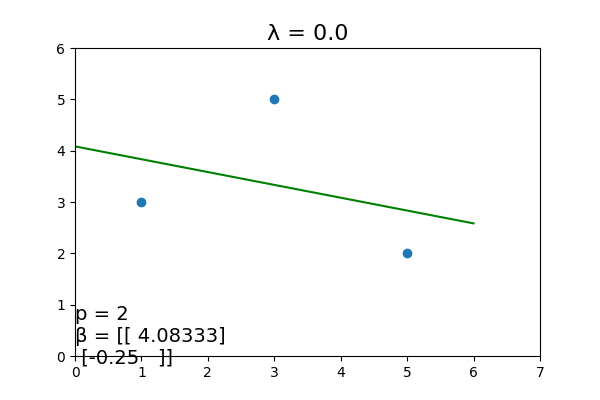

In [6]:
%matplotlib widget

fig, ax = plt.subplots(figsize=(6, 4))
ax.set_ylim([0, 6])
ax.set_xlim([0, 7])

txt = plt.text(0, 1, f"β = []",
            fontsize=14,
            horizontalalignment='left',
            verticalalignment='top'
)
plt.scatter(D, y)
xs = np.linspace(D.min()-1, D.max()+1)

@widgets.interact(λ=(0, 5, .02), k=(0, 5, 1))
def update(λ=0, k=1, penalize_bias=True):
    [l.remove() for l in ax.lines]
    try:
        β = fit_with_penalty(D, y, ϕ_p(k), λ, penalize_bias)
    except np.linalg.LinAlgError as e:
        txt.set_text(f"{e}")
        return
    ys_pred = predict(xs, ϕ_p(k), β)
    plt.plot(xs, ys_pred, color='g')
    # plt.tight_layout()
    ax.set_title(f"λ = {λ}", size=16)
    txt.set_text(f"p = {k + 1}\nβ = {β}")
